In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle



In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test sets from SDF files
test_df = load_sdf_to_df(
    r"D:\Riset QSAR - TTX\Machine Learning (Done)\Eye\Dataset\test_set_eye_irritation_features_rdkitcdk.sdf"
)

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())

print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
  Outcome                                 Morgan_Descriptors  \
0       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, ...   
2       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0  [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor    ID  \
0  [0.04791643691944794, 0.800311806350089, 0.872...  2101   
1  [-0.47754646001907536, -0.8830342345716835, -0...   771   
2  [-0.13311749014425403, 1.5412168620442561, 0.9...   246   
3  [1.43297702

In [3]:
test_df.keys()

Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'],
      dtype='object')

In [4]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

In [5]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
#moldf['RowID'] = moldf.index
test_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,1.0,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0
375,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25014201490384613, 0.3787487110664767, 0.4...",2105,CC[N+](C)(C)Cc1ccccc1Br,242.05388806409,3.0454000000000017,89.09346645392004,0.0,...,0.0,2.0,4.0,0.4285714285714285,3.0,0.0,0.0,4.700439718141093,2.803,0.4545454545454545
178,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.788399316301848, -0.8542147590372908, -0.83...",1186,CCCCCCCCCCCCCCCCCCCCCCO,326.35486609199995,7.800600000000008,147.19726918235438,20.23,...,1.0,22.0,23.0,0.5,20.0,2.0,20.23,5.459431618637297,11.093000000000004,1.0
179,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8246546821741206, -0.788580992353336, -0.7...",1417,CC(=O)OCC(C)C,116.083729624,1.2055,49.83902892936323,26.3,...,0.0,3.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.319,0.8333333333333334
372,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43891279084130047, -0.20770642468642303, -0...",1351,CCCCC(CC)COC(=O)OCC(CC)CCCC,286.250794948,5.572400000000006,124.9669374172328,35.53,...,0.0,7.0,15.0,0.5,14.0,2.0,35.53,5.247927513443585,7.119999999999999,0.9411764705882352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.739548432578458, 0.6231803655504822, 0.6896...",1435,Cc1cccc(Cc2ccccc2)c1Cc1ccccc1,272.15650064,5.176620000000004,126.64041787481489,0.0,...,0.0,0.0,0.0,0.4545454545454545,4.0,1.0,0.0,5.523561956057013,6.391,0.1428571428571428
266,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2905532634779706, 1.7861486348773434, 1.764...",2148,CC(=O)OC1(C(C)=O)CCC2C3C=C(C)C4=CC(=O)CCC4(C)C...,384.230059504,4.575300000000005,167.32850051010428,60.440000000000005,...,0.0,2.0,3.0,0.5,3.0,0.0,60.440000000000005,5.954196310386876,4.049,0.7083333333333334
263,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.37779552785841425, -0.8830342345716826, -0....",1265,CCCCCCCCC=CCCCCCCCCO,268.276615772,6.0162000000000075,121.04789769258367,20.23,...,1.0,18.0,19.0,0.5,15.0,2.0,20.23,5.169925001442312,8.301,0.8888888888888888
224,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.6591994500047212, 0.6588320262229757, 0.726...",1875,CC[N+](C)(C)C(C)CC(c1ccccc1)c1ccccc1,282.22162631609,4.693400000000004,129.3778393975326,0.0,...,0.0,4.0,6.0,0.4444444444444444,6.0,0.0,0.0,5.459431618637297,4.471,0.4


Classes                          :  ['0' '1']
Number of cpds in each class     :  [223, 234]
Total number of cpds             :  457
Class mapping:  {0: 0, 1: 1}


{0: 0, 1: 1}

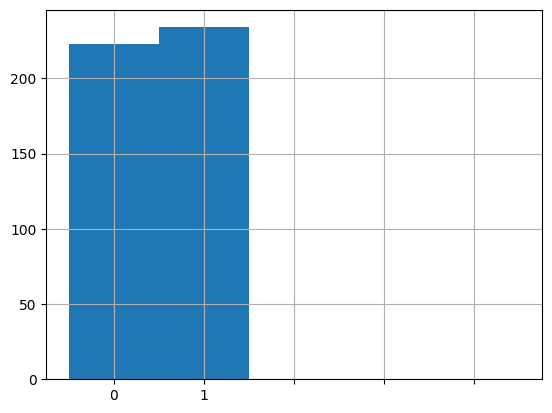

In [6]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info




In [7]:
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,1.0,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0
375,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25014201490384613, 0.3787487110664767, 0.4...",2105,CC[N+](C)(C)Cc1ccccc1Br,242.05388806409,3.0454000000000017,89.09346645392004,0.0,...,0.0,2.0,4.0,0.4285714285714285,3.0,0.0,0.0,4.700439718141093,2.803,0.4545454545454545
178,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.788399316301848, -0.8542147590372908, -0.83...",1186,CCCCCCCCCCCCCCCCCCCCCCO,326.35486609199995,7.800600000000008,147.19726918235438,20.23,...,1.0,22.0,23.0,0.5,20.0,2.0,20.23,5.459431618637297,11.093000000000004,1.0
179,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8246546821741206, -0.788580992353336, -0.7...",1417,CC(=O)OCC(C)C,116.083729624,1.2055,49.83902892936323,26.3,...,0.0,3.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.319,0.8333333333333334
372,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43891279084130047, -0.20770642468642303, -0...",1351,CCCCC(CC)COC(=O)OCC(CC)CCCC,286.250794948,5.572400000000006,124.9669374172328,35.53,...,0.0,7.0,15.0,0.5,14.0,2.0,35.53,5.247927513443585,7.119999999999999,0.9411764705882352
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2594996877202358, -0.3870431626392465, -0.3...",1091,CCCCCCCCCCCC(=O)OOC(=O)CCCCCCCCCCC,398.339609952,7.829600000000009,173.6123496337912,52.6,...,0.0,12.0,26.0,0.48,23.0,2.0,52.6,5.754887502163469,10.634000000000002,0.9166666666666666
209,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9332454506985439, 0.49420738439285267, 0.55...",110,CCC(C)=NO[Si](ON=C(C)CC)(ON=C(C)CC)ON=C(C)CC,372.219282034,4.632000000000004,151.9393089641687,86.36,...,0.0,4.0,11.0,0.5,12.0,2.0,86.36,5.584962500721157,5.231999999999999,0.75
207,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8281554438780846, 0.03353380012611593, -0....",74,Cc1nccn1C,96.06874825599999,0.72852,42.80006723684632,17.82,...,0.0,0.0,0.0,0.3333333333333333,0.0,0.0,17.82,3.807354922057604,0.502,0.4
203,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5902447527987297, -0.21717699472312912, -0...",471,O=C=Nc1ccccc1,119.03711378,1.6539,52.85318981979746,29.43,...,0.0,0.0,3.0,0.5,1.0,0.0,29.43,4.169925001442312,3.2860000000000005,0.0


In [8]:
x_rdkitcdk = test_df.drop(columns=['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP'])

In [9]:
print(x_rdkitcdk)

              LabuteASA   TPSA                 AMW NumLipinskiHBA  \
0     87.15563838100506  12.03             199.278              2   
375   89.09346645392004    0.0  243.16799999999998              0   
178  147.19726918235438  20.23  326.60900000000004              1   
179   49.83902892936323   26.3              116.16              2   
372   124.9669374172328  35.53             286.456              3   
..                  ...    ...                 ...            ...   
210   173.6123496337912   52.6   398.6280000000004              4   
209   151.9393089641687  86.36  372.54200000000014              8   
207   42.80006723684632  17.82              96.133              2   
203   52.85318981979746  29.43  119.12299999999995              2   
456    78.1216554413723   74.6  210.27599999999998              4   

    NumLipinskiHBD NumRotatableBonds NumHBD NumHBA NumAmideBonds  \
0                1                 0      1      2             0   
375              0                 

In [10]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

    Outcome                                 Morgan_Descriptors  \
0         0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
375       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
178       0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
179       0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...   
372       0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..      ...                                                ...   
210       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
209       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
207       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
203       1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
456       1  [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                     MACCS_Descriptors  \
0    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
375  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
178  [0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [11]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [12]:
x_test_rdkit_cdk

array([['87.15563838100506', '12.03', '199.278', ..., '5.0',
        '3.786000000000001', '0.0'],
       ['89.09346645392004', '0.0', '243.16799999999998', ...,
        '4.700439718141093', '2.803', '0.4545454545454545'],
       ['147.19726918235438', '20.23', '326.60900000000004', ...,
        '5.459431618637297', '11.093000000000004', '1.0'],
       ...,
       ['42.80006723684632', '17.82', '96.133', ..., '3.807354922057604',
        '0.502', '0.4'],
       ['52.85318981979746', '29.43', '119.12299999999995', ...,
        '4.169925001442312', '3.2860000000000005', '0.0'],
       ['78.1216554413723', '74.6', '210.27599999999998', ...,
        '4.459431618637298', '0.5159999999999998', '0.6666666666666666']],
      dtype=object)

In [13]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [14]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [15]:
# load code
# load model - all included
import joblib

# Base paths
desc_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Eye\Model\Descriptor"
phys_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Eye\Model\Physiochemical"

# descriptor
rf_morgan   = joblib.load(fr"{desc_path}\Model_Eye_RF_morgan.pkl")  
rf_maccs    = joblib.load(fr"{desc_path}\Model_Eye_RF_maccskey.pkl")
rf_modred   = joblib.load(fr"{desc_path}\Model_Eye_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{desc_path}\Model_Eye_SVM_morgan.pkl")  
svm_maccs   = joblib.load(fr"{desc_path}\Model_Eye_SVM_maccskey.pkl")
svm_modred  = joblib.load(fr"{desc_path}\Model_Eye_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{desc_path}\Model_Eye_XGB_morgan.pkl")  
xgb_maccs   = joblib.load(fr"{desc_path}\Model_Eye_XGB_maccskey.pkl")
xgb_modred  = joblib.load(fr"{desc_path}\Model_Eye_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{desc_path}\Model_Eye_NN_morgan.pkl")  
nn_maccs    = joblib.load(fr"{desc_path}\Model_Eye_NN_maccskey.pkl")
nn_modred   = joblib.load(fr"{desc_path}\Model_Eye_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{desc_path}\Model_Eye_LGBM_morgan.pkl")  
lgbm_maccs  = joblib.load(fr"{desc_path}\Model_Eye_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{desc_path}\Model_Eye_LGBM_modred.pkl")

# physiochemical
rf_phys   = joblib.load(fr"{phys_path}\Model_Eye_RF_phys.pkl")
svm_phys  = joblib.load(fr"{phys_path}\Model_Eye_SVM_phys.pkl")
xgb_phys  = joblib.load(fr"{phys_path}\Model_Eye_XGB_phys.pkl")
nn_phys   = joblib.load(fr"{phys_path}\Model_Eye_NN_phys.pkl")
lgbm_phys = joblib.load(fr"{phys_path}\Model_Eye_LGBM_phys.pkl")


In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [17]:
x_test
test_df

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,rdkit_cdk
0,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.04791643691944794, 0.800311806350089, 0.872...",2101,c1ccc2c(c1)Nc1ccccc1S2,199.045570288,3.894800000000001,87.15563838100506,12.03,...,0.0,0.0,0.4285714285714285,0.0,0.0,37.33,5.0,3.786000000000001,0.0,"[87.15563838100506, 12.03, 199.278, 2, 1, 0, 1..."
375,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.25014201490384613, 0.3787487110664767, 0.4...",2105,CC[N+](C)(C)Cc1ccccc1Br,242.05388806409,3.0454000000000017,89.09346645392004,0.0,...,2.0,4.0,0.4285714285714285,3.0,0.0,0.0,4.700439718141093,2.803,0.4545454545454545,"[89.09346645392004, 0.0, 243.16799999999998, 0..."
178,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.788399316301848, -0.8542147590372908, -0.83...",1186,CCCCCCCCCCCCCCCCCCCCCCO,326.35486609199995,7.800600000000008,147.19726918235438,20.23,...,22.0,23.0,0.5,20.0,2.0,20.23,5.459431618637297,11.093000000000004,1.0,"[147.19726918235438, 20.23, 326.60900000000004..."
179,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8246546821741206, -0.788580992353336, -0.7...",1417,CC(=O)OCC(C)C,116.083729624,1.2055,49.83902892936323,26.3,...,3.0,6.0,0.4,3.0,0.0,26.3,3.807354922057604,1.319,0.8333333333333334,"[49.83902892936323, 26.3, 116.16, 2, 0, 2, 0, ..."
372,0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.43891279084130047, -0.20770642468642303, -0...",1351,CCCCC(CC)COC(=O)OCC(CC)CCCC,286.250794948,5.572400000000006,124.9669374172328,35.53,...,7.0,15.0,0.5,14.0,2.0,35.53,5.247927513443585,7.119999999999999,0.9411764705882352,"[124.9669374172328, 35.53, 286.456, 3, 0, 12, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2594996877202358, -0.3870431626392465, -0.3...",1091,CCCCCCCCCCCC(=O)OOC(=O)CCCCCCCCCCC,398.339609952,7.829600000000009,173.6123496337912,52.6,...,12.0,26.0,0.48,23.0,2.0,52.6,5.754887502163469,10.634000000000002,0.9166666666666666,"[173.6123496337912, 52.6, 398.6280000000004, 4..."
209,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.9332454506985439, 0.49420738439285267, 0.55...",110,CCC(C)=NO[Si](ON=C(C)CC)(ON=C(C)CC)ON=C(C)CC,372.219282034,4.632000000000004,151.9393089641687,86.36,...,4.0,11.0,0.5,12.0,2.0,86.36,5.584962500721157,5.231999999999999,0.75,"[151.9393089641687, 86.36, 372.54200000000014,..."
207,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8281554438780846, 0.03353380012611593, -0....",74,Cc1nccn1C,96.06874825599999,0.72852,42.80006723684632,17.82,...,0.0,0.0,0.3333333333333333,0.0,0.0,17.82,3.807354922057604,0.502,0.4,"[42.80006723684632, 17.82, 96.133, 2, 0, 0, 0,..."
203,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5902447527987297, -0.21717699472312912, -0...",471,O=C=Nc1ccccc1,119.03711378,1.6539,52.85318981979746,29.43,...,0.0,3.0,0.5,1.0,0.0,29.43,4.169925001442312,3.2860000000000005,0.0,"[52.85318981979746, 29.43, 119.12299999999995,..."


In [18]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# ==============================
# Run prediction
# ==============================
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# ==============================
# Evaluate performance
# ==============================
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[150  73]
 [ 56 178]]
Accuracy: 0.7177242888402626
AUC Score: 0.7972480932122187
F1 Score: 0.734020618556701
Sensitivity: 0.7606837606837606
Specificity: 0.672645739910314
CCR (Correct Classification Rate): 0.7166647502970374
PPV (Positive Predictive Value): 0.7091633466135459
NPV (Negative Predictive Value): 0.7281553398058253


In [ ]:
#individual test descriptor

In [19]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[146  77]
 [ 68 166]]
Accuracy: 0.6827133479212254
AUC: 0.7263999080142578
F1 Score: 0.6960167714884696
Sensitivity: 0.7094017094017094
Specificity: 0.6547085201793722
CCR: 0.6820551147905408
PPV (Precision): 0.6831275720164609
NPV: 0.6822429906542056

MACCS RF Performance
Confusion Matrix: [[147  76]
 [ 60 174]]
Accuracy: 0.7024070021881839
AUC: 0.7700548081714002
F1 Score: 0.71900826446281
Sensitivity: 0.7435897435897436
Specificity: 0.6591928251121076
CCR: 0.7013912843509256
PPV (Precision): 0.696
NPV: 0.7101449275362319

Modred RF Performance
Confusion Matrix: [[154  69]
 [ 52 182]]
Accuracy: 0.7352297592997812
AUC: 0.7983308420528151
F1 Score: 0.7505154639175258
Sensitivity: 0.7777777777777778
Specificity: 0.6905829596412556
CCR: 0.7341803687095168
PPV (Precision): 0.7250996015936255
NPV: 0.7475728155339806

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[156  67]
 [ 58 176]]
Accuracy: 0.7264770240700219
AUC: 0.7903779080909126


In [20]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[149  74]
 [ 69 165]]
Accuracy: 0.687089715536105
AUC: 0.7345348970909509
F1 Score: 0.6976744186046512
Sensitivity (Recall+): 0.7051282051282052
Specificity (Recall-): 0.6681614349775785
CCR: 0.6866448200528918
PPV (Precision): 0.6903765690376569
NPV: 0.6834862385321101

MACCS SVM Performance
Confusion Matrix: [[163  60]
 [ 63 171]]
Accuracy: 0.7308533916849015
AUC: 0.7743091487486107
F1 Score: 0.7354838709677419
Sensitivity (Recall+): 0.7307692307692307
Specificity (Recall-): 0.7309417040358744
CCR: 0.7308554674025526
PPV (Precision): 0.7402597402597403
NPV: 0.7212389380530974

Modred SVM Performance
Confusion Matrix: [[157  66]
 [ 66 168]]
Accuracy: 0.7111597374179431
AUC: 0.7910486374611935
F1 Score: 0.717948717948718
Sensitivity (Recall+): 0.717948717948718
Specificity (Recall-): 0.7040358744394619
CCR: 0.71099229619409
PPV (Precision): 0.717948717948718
NPV: 0.7040358744394619

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix: [[1

In [21]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[149  74]
 [ 67 167]]
Accuracy: 0.6914660831509847
AUC: 0.7589207006247365
F1 Score: 0.7031578947368421
Sensitivity (Recall+): 0.7136752136752137
Specificity (Recall-): 0.6681614349775785
CCR: 0.6909183243263961
PPV (Precision): 0.6929460580912863
NPV: 0.6898148148148148

MACCS XGB Performance
Confusion Matrix: [[154  69]
 [ 69 165]]
Accuracy: 0.6980306345733042
AUC: 0.7644206814610403
F1 Score: 0.7051282051282052
Sensitivity (Recall+): 0.7051282051282052
Specificity (Recall-): 0.6905829596412556
CCR: 0.6978555823847303
PPV (Precision): 0.7051282051282052
NPV: 0.6905829596412556

Modred XGB Performance
Confusion Matrix: [[152  71]
 [ 64 170]]
Accuracy: 0.7045951859956237
AUC: 0.7861714767544364
F1 Score: 0.7157894736842105
Sensitivity (Recall+): 0.7264957264957265
Specificity (Recall-): 0.6816143497757847
CCR: 0.7040550381357555
PPV (Precision): 0.7053941908713693
NPV: 0.7037037037037037

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matri

In [22]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[137  86]
 [ 90 144]]
Accuracy: 0.6148796498905909
AUC: 0.6895481200413935
F1 Score: 0.6206896551724138
Sensitivity (Recall+): 0.6153846153846154
Specificity (Recall-): 0.6143497757847534
CCR: 0.6148671955846844
PPV (Precision): 0.6260869565217392
NPV: 0.6035242290748899

MACCS Performance
Confusion Matrix: [[138  85]
 [ 70 164]]
Accuracy: 0.6608315098468271
AUC: 0.7320531984209115
F1 Score: 0.6790890269151139
Sensitivity (Recall+): 0.7008547008547008
Specificity (Recall-): 0.6188340807174888
CCR: 0.6598443907860948
PPV (Precision): 0.6586345381526104
NPV: 0.6634615384615384

Modred Performance
Confusion Matrix: [[162  61]
 [ 70 164]]
Accuracy: 0.7133479212253829
AUC: 0.7966731823234066
F1 Score: 0.7145969498910676
Sensitivity (Recall+): 0.7008547008547008
Specificity (Recall-): 0.726457399103139
CCR: 0.71365604997892
PPV (Precision): 0.7288888888888889
NPV: 0.6982758620689655

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[154  69]


In [23]:
# LGBM - Consensus
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[142  81]
 [ 76 158]]
Accuracy: 0.6564551422319475
AUC: 0.7294469357249627
F1 Score: 0.6680761099365751
Sensitivity (Recall+): 0.6752136752136753
Specificity (Recall-): 0.6367713004484304
CCR: 0.6559924878310528
PPV (Precision): 0.6610878661087866
NPV: 0.6513761467889908

===== MACCS Performance =====
Confusion Matrix: [[154  69]
 [ 67 167]]
Accuracy: 0.7024070021881839
AUC: 0.7587865547506805
F1 Score: 0.7106382978723405
Sensitivity (Recall+): 0.7136752136752137
Specificity (Recall-): 0.6905829596412556
CCR: 0.7021290866582346
PPV (Precision): 0.7076271186440678
NPV: 0.6968325791855203

===== Modred Performance =====
Confusion Matrix: [[153  70]
 [ 58 176]]
Accuracy: 0.7199124726477024
AUC: 0.7850983097619868
F1 Score: 0.7333333333333333
Sensitivity (Recall+): 0.7521367521367521
Specificity (Recall-): 0.6860986547085202
CCR: 0.7191177034226361
PPV (Precision): 0.7154471544715447
NPV: 0.7251184834123223

===== CONSENSUS LGBM (Morgan + 

In [24]:
# ==============================
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
# ==============================
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[158  65]
 [ 56 178]]
Accuracy: 0.7352297592997812
AUC: 0.8019431988041854
F1 Score: 0.7463312368972747
Sensitivity (Recall+): 0.7606837606837606
Specificity (Recall-): 0.7085201793721974
CCR: 0.734601970027979
PPV (Precision): 0.7325102880658436
NPV: 0.7383177570093458


In [25]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[157  66]
 [ 57 177]]
Accuracy: 0.7308533916849015
AUC: 0.8091870760032195
F1 Score: 0.7421383647798742
Sensitivity (Recall+): 0.7564102564102564
Specificity (Recall-): 0.7040358744394619
CCR: 0.7302230654248592
PPV (Precision): 0.7283950617283951
NPV: 0.7336448598130841


In [ ]:
#read accross

In [26]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6564551422319475
AUC: 0.6969548886589245
F1 Score: 0.6789366053169734
Sensitivity (Recall+): 0.7094017094017094
Specificity (Recall-): 0.600896860986547
CCR: 0.6551492851941283
PPV (Precision): 0.6509803921568628
NPV: 0.6633663366336634


In [27]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6564551422319475
AUC: 0.6969548886589245
F1 Score: 0.6789366053169734
Sensitivity (Recall+): 0.7094017094017094
Specificity (Recall-): 0.600896860986547
CCR: 0.6551492851941283
PPV (Precision): 0.6509803921568628
NPV: 0.6633663366336634

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[158  65]
 [ 56 178]]
Accuracy: 0.7352297592997812
AUC: 0.8019431988041854
F1 Score: 0.7463312368972747
Sensitivity (Recall+): 0.7606837606837606
Specificity (Recall-): 0.7085201793721974
CCR: 0.734601970027979
PPV (Precision): 0.7325102880658436
NPV: 0.7383177570093458

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.7177242888402626
AUC: 0.7972480932122187
F1 Score: 0.734020618556701
Sensitivity (Recall+): 0.7606837606837606
Specificity (Recall-): 0.672645739910314
CCR: 0.7166647502970374
PPV (Precision): 0.7091633466135459
NP